In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
#     CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxxx"
#     CHECKPOINT_FILE = "step_0.pt"


# Lagrangian Isometries with Normalizing Flows

Here, we demonstrate isometries that involve a parameterized diffeomorphism $\Phi: \Omega \to \Omega$ and are formulated as the isometric pullback:

$$(Q_\Phi f) (x)= f(\Phi(x)) \cdot \sqrt{|\det J_{\Phi}(x)|}$$

The fact that this is an isometry can be easily verified using change of variables:

\begin{align}
\langle Q_\Phi f, Q_\Phi g \rangle & = \int (Q_\Phi f) (x)\, (Q_\Phi g) (x) \, dx\\
& = \int f (\Phi(x)) \, g (\Phi(x)) \, |\det J_{\Phi}(x)| \, dx\\
& = \int f(u) \, g(u) \, du \qquad \text{where } u = \Phi(x), \text{ and } du = dx \cdot |\det J_{\Phi}(x)|\\
& = \langle f , g \rangle.
\end{align}

Let's start by running basic imports:

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Here, we instatiate different normalizing flows that act on the square domain $\Omega = [0, 1]^2$:

In [2]:
%autoreload 2
from infidictionary.diffeomorphisms import UnitCubeNeuralSplineFlow
from infidictionary.diffeomorphisms import UnitSquareKumaraswamy

####
# Toggle between diffeomorphisms here:
# T = UnitCubeNeuralSplineFlow(d=2, hidden_features=64, num_layers=5, num_blocks=2, alpha=0.00005)
T = UnitSquareKumaraswamy(d=2, eps=1e-6, a_min=1, b_min=0.5)

T = T.to(device)

You may toggle between any of the above diffeomirphisms. Here is a brief explanation for each of them:
1. The `UnitCubeNeuralSplineFlow` is based on neural spline flows, a flexible diffeomorphism parameterized using spline couplings. Note that spline flows parmeterize diffeomirphisms on $\mathbb{R}^d$, we therefore perform a coordinatewise logit transform first to map values from $[0, 1]^2$ to $\mathbb{R}^d$, apply the neural spline flow, and then perform an inverse logit (sigmoid) to transform everything back to $[0, 1]^2$.

2. The `UnitSquareKumaraswamy` is based on an elementwise Kumaraswamy transform where each coordinate $x$ is mapped to $1 - (1 - x^a)^b$ and $a$ and $b$ are learnable parameters of the transform. This transformation is a diffeomorphism on $[0, 1]^d$ when applied elementwise and is primarily used for debugging purposes as a simple drop-in flow map.

Run the following code to visualize how these normalizing flows deform the particles:

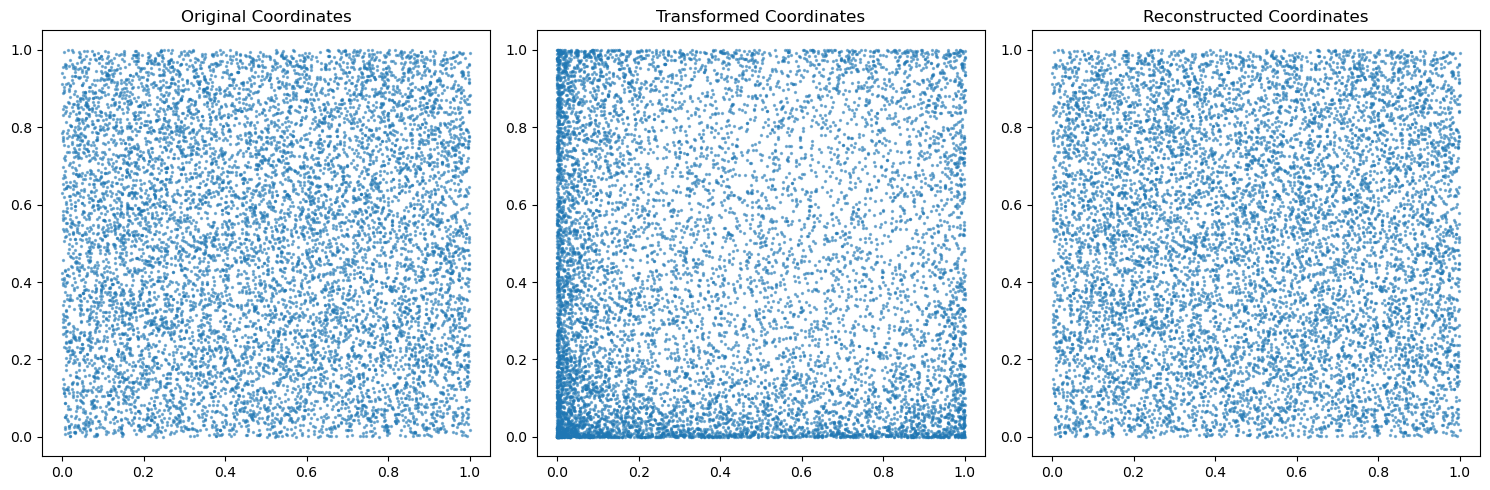

In [3]:
%autoreload 2
from infidictionary.domain_samplers import SquareSampler

coords = SquareSampler().sample(100).to(device)
coords_transformed, detJ = T.forward(coords)
coords_reconstructed, detJ_inv = T.inverse(coords_transformed)

#  check y max and min is in the box
assert (coords_transformed >= 0).all() and (coords_transformed <= 1).all()
assert (coords - coords_reconstructed).abs().max().item() < 1e-6
assert (torch.exp(detJ + detJ_inv) - 1).abs().max().item() < 1e-6

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
ax[0].scatter(
    coords[:,0].detach().cpu(), 
    coords[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[0].set_title('Original Coordinates')
ax[1].scatter(
    coords_transformed[:,0].detach().cpu(), 
    coords_transformed[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[1].set_title('Transformed Coordinates')
ax[2].scatter(
    coords_reconstructed[:,0].detach().cpu(), 
    coords_reconstructed[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[2].set_title('Reconstructed Coordinates')
plt.tight_layout()

Next, use the Lagrangian isometry API-the same that is used for change of domain-to define the isometry $Q_\Phi$. Use this transformation to change the box basis:

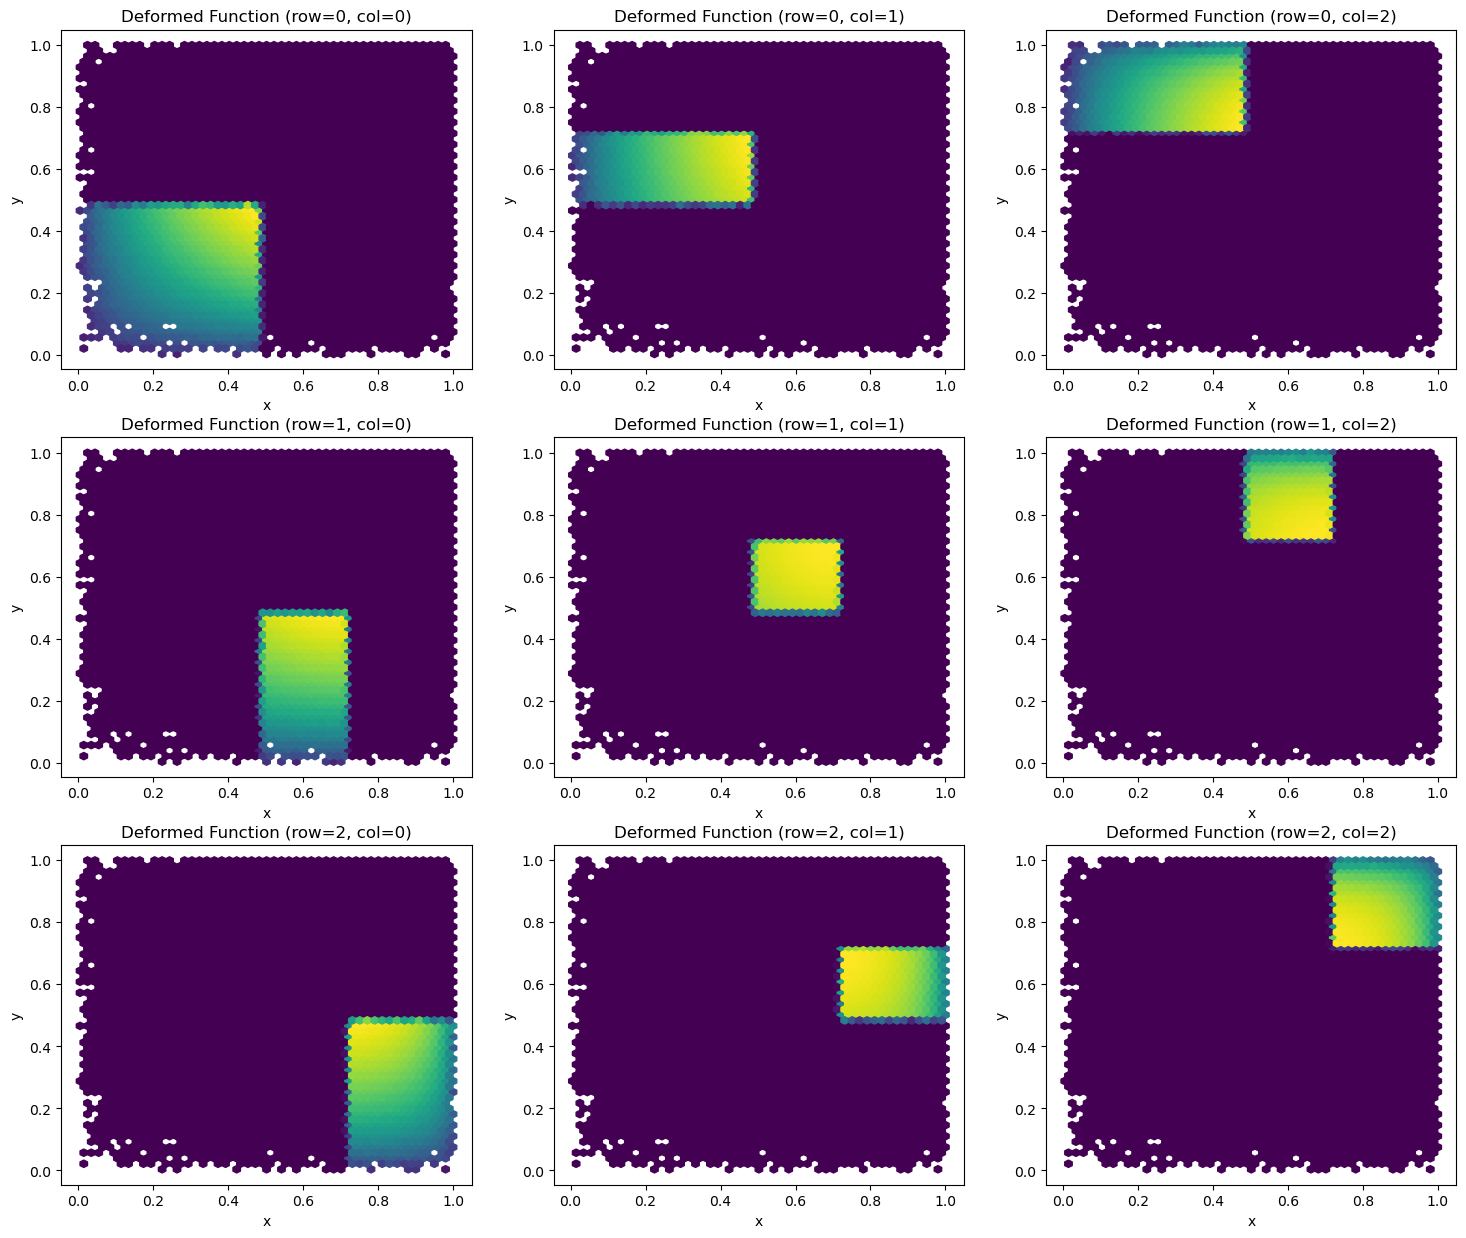

In [4]:
%autoreload 2
from infidictionary.dictionaries import BoxDictionary
from infidictionary.domain_samplers import SquareSampler
from infidictionary.neural_isometries import LagrangianIsometry

N_per_dim = 250
isometry = LagrangianIsometry(diffeomorphism=T)
tent_basis = BoxDictionary(
    resolution=3,
    num_channels=1,
    domain_dim=2,
)
indices = [
    [[0, 0], [0, 1], [0, 2]],
    [[1, 0], [1, 1], [1, 2]],
    [[2, 0], [2, 1], [2, 2]],
]
indices_tensorized = torch.tensor(indices).reshape(-1, 2).to(device)
fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
xy = SquareSampler().sample(N_per_dim).to(device)
all_vals = tent_basis.get_atoms(xy, indices_tensorized)
deformed_xy, logabsdet, all_deformed_vals = isometry.pullback(
    tgt_coords=xy,
    tgt_logabsdet=torch.zeros(xy.shape[0], device=xy.device),
    tgt_field=all_vals,
)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.hexbin(
            deformed_xy[:,0].detach().cpu(), 
            deformed_xy[:,1].detach().cpu(), 
            C=all_deformed_vals[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        ax.set_title(f'Deformed Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

Compute the pairwise inner products and compare them before and after deforming the function:

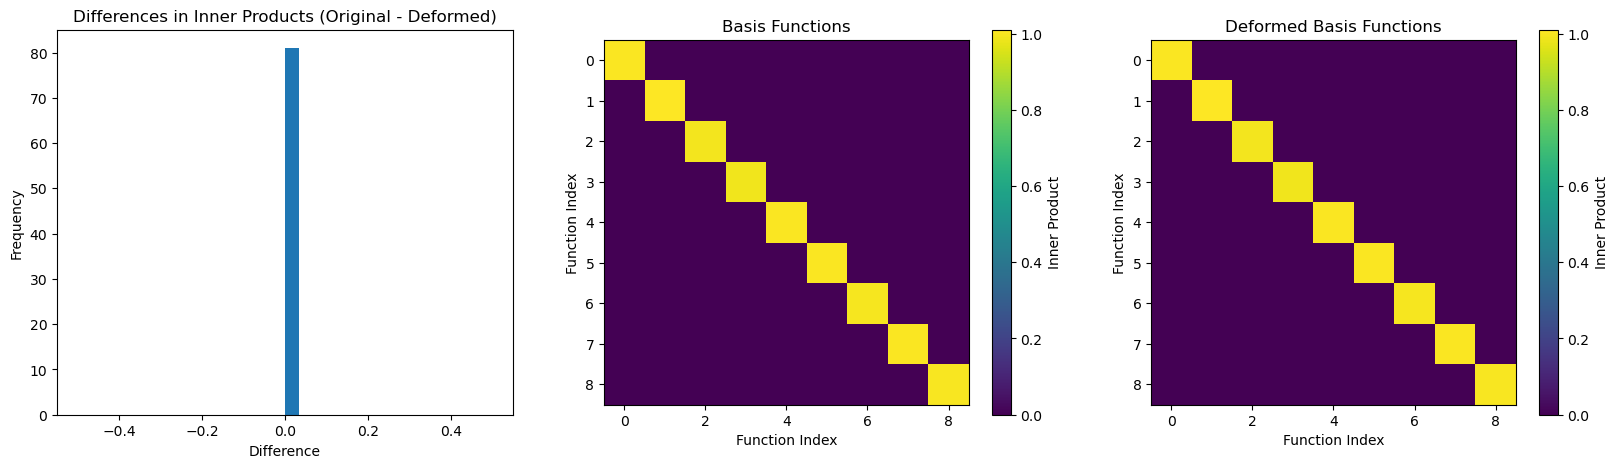

In [5]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product
# compute pairwise inner products
inner_products = pairwise_inner_product(all_vals, all_vals)
inner_products_deformed = pairwise_inner_product(all_deformed_vals, all_deformed_vals, logabsdet=logabsdet)
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


A similar implementation is done for the functions on disk domains. Here, points in the unit disk are first converted to the polar coordinate and rescaled so that everything lies in $[0, 1]^2$, passed through one of the diffeomorphisms defined on $[0, 1]^2$ and then transformed back to the cartesian coordinates. Run the following to visualize the disk domain flows:

In [6]:
%autoreload 2
from infidictionary.diffeomorphisms import UnitCubeNeuralSplineFlow
from infidictionary.diffeomorphisms import UnitSquareKumaraswamy
from infidictionary.diffeomorphisms import DiskFlow

####
# Toggle between diffeomorphisms here:
cubeflow = UnitCubeNeuralSplineFlow(d=2, hidden_features=64, num_layers=5, num_blocks=2, alpha=0.00005)
# cubeflow = UnitSquareKumaraswamy(d=2, eps=1e-6, a_min=1, b_min=0.5)
T = DiskFlow(cubeflow=cubeflow, method='shirley_chiu')

T = T.to(device)


View particles before and after the transform on the unit disk:

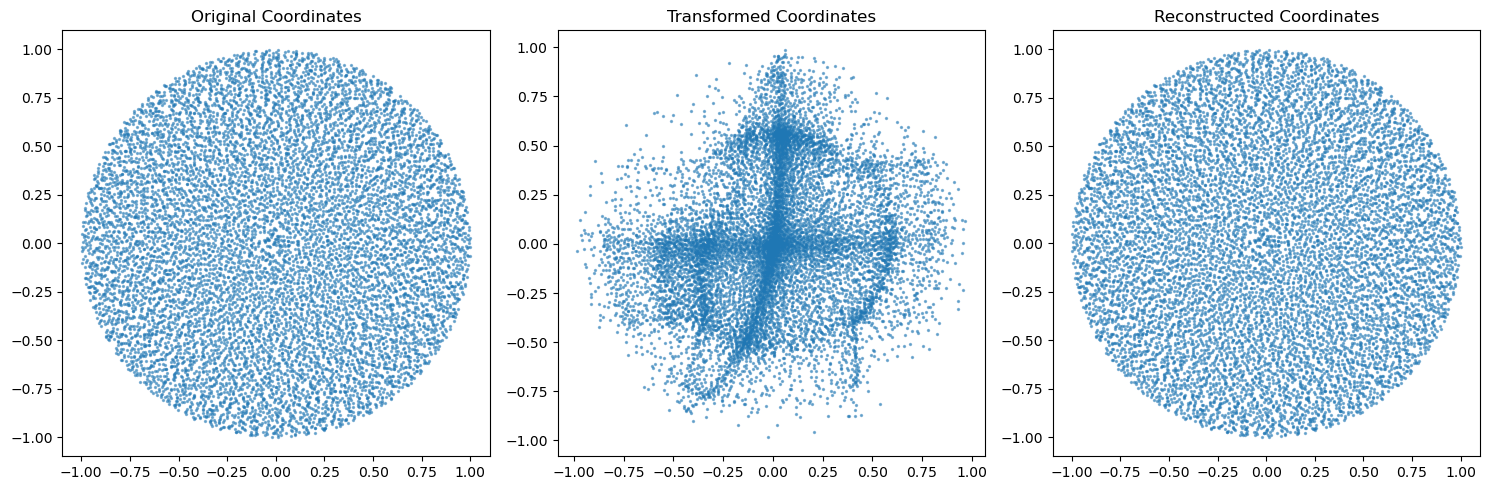

In [11]:
%autoreload 2
from infidictionary.domain_samplers import DiskSampler

coords = DiskSampler().sample(100).to(device)
coords_transformed, detJ = T.forward(coords)
coords_reconstructed, detJ_inv = T.inverse(coords_transformed)

#  check y max and min is in the box
assert (torch.norm(coords_transformed, dim=-1) <= 1).all()
assert (coords - coords_reconstructed).abs().max().item() < 1e-6
assert (torch.exp(detJ + detJ_inv) - 1).abs().max().item() < 1e-6

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
ax[0].scatter(
    coords[:,0].detach().cpu(), 
    coords[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[0].set_title('Original Coordinates')
ax[1].scatter(
    coords_transformed[:,0].detach().cpu(), 
    coords_transformed[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[1].set_title('Transformed Coordinates')
ax[2].scatter(
    coords_reconstructed[:,0].detach().cpu(), 
    coords_reconstructed[:,1].detach().cpu(), 
    s=2, 
    alpha=0.5,
)
ax[2].set_title('Reconstructed Coordinates')
plt.tight_layout()

Now, first push the box basis through a change of domain isometry, followed by the isometry defined on the disk through the above transformation:

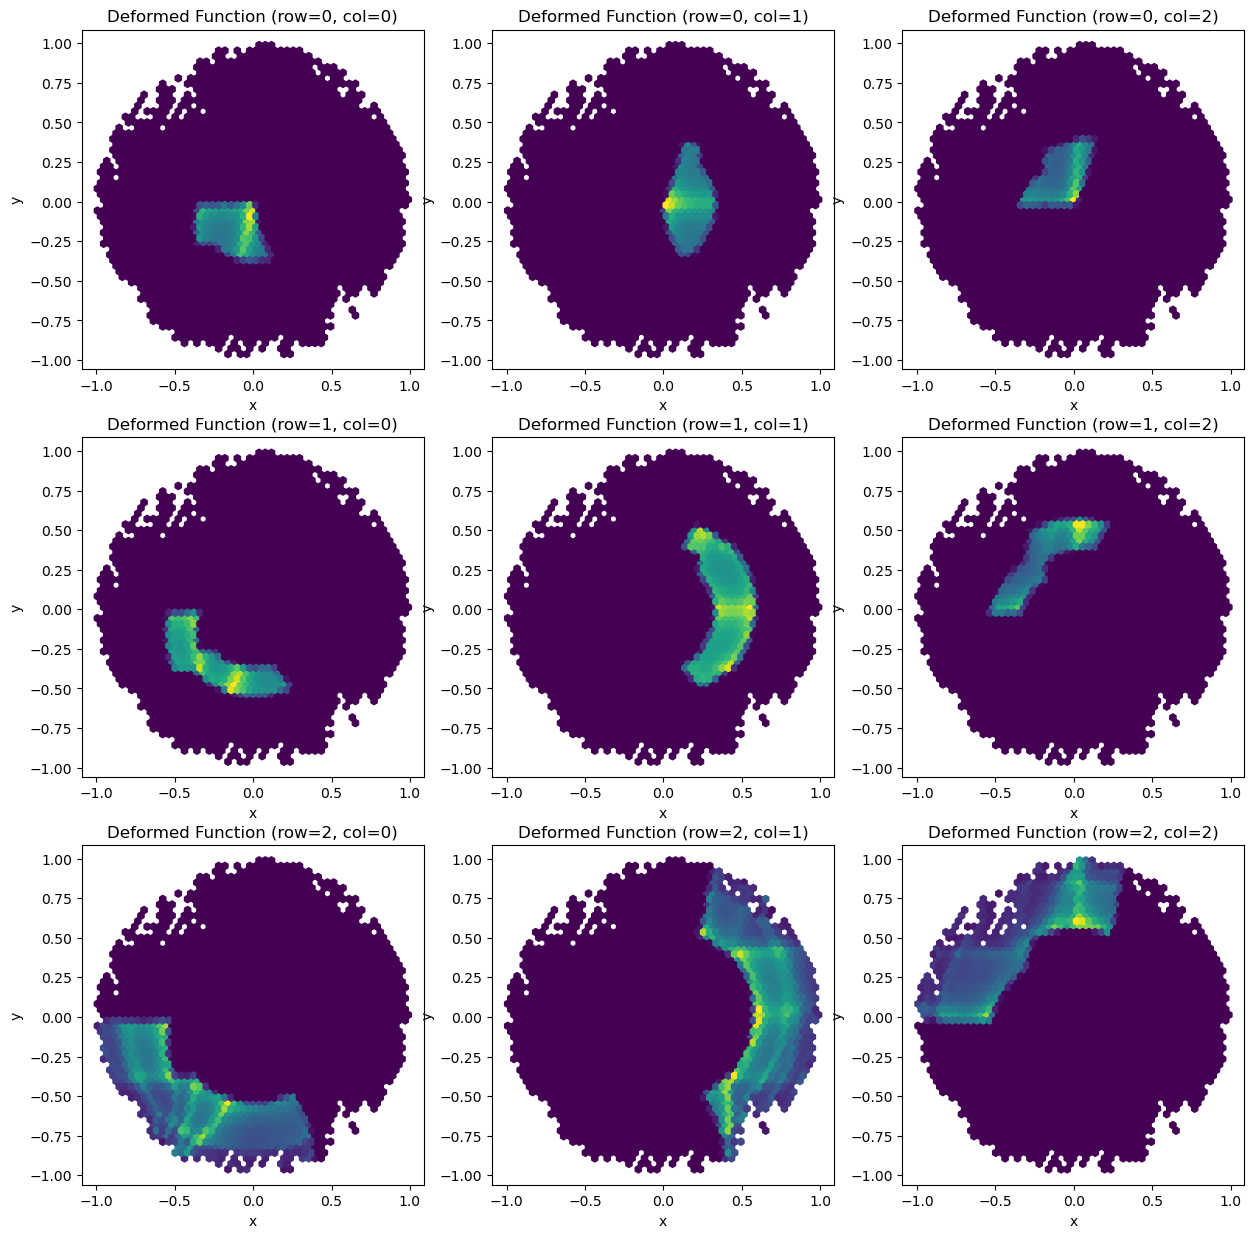

In [15]:
%autoreload 2
from infidictionary.dictionaries import BoxDictionary
from infidictionary.diffeomorphisms import ShirlyChiu, PolarTransform
from infidictionary.domain_samplers import SquareSampler
from infidictionary.neural_isometries import LagrangianIsometry

N_per_dim = 250
change_of_domain = LagrangianIsometry(diffeomorphism=PolarTransform())
isometry = LagrangianIsometry(diffeomorphism=T)
tent_basis = BoxDictionary(
    resolution=3,
    num_channels=1,
    domain_dim=2,
)
indices = [
    [[0, 0], [0, 1], [0, 2]],
    [[1, 0], [1, 1], [1, 2]],
    [[2, 0], [2, 1], [2, 2]],
]
indices_tensorized = torch.tensor(indices).reshape(-1, 2).to(device)
fig, axes = plt.subplots(figsize=(5 * 3,5 * 3), nrows=3, ncols=3)
xy = SquareSampler().sample(N_per_dim).to(device)
all_vals = tent_basis.get_atoms(xy, indices_tensorized)
interim_xy, interim_logabsdet, interim_vals = change_of_domain.pushforward(
    src_coords=xy,
    src_logabsdet=torch.zeros(xy.shape[0], device=xy.device),
    src_field=all_vals,
)
deformed_xy, logabsdet, all_deformed_vals = isometry.pushforward(
    src_coords=interim_xy,
    src_logabsdet=interim_logabsdet,
    src_field=interim_vals,
)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.hexbin(
            deformed_xy[:,0].detach().cpu(), 
            deformed_xy[:,1].detach().cpu(), 
            C=all_deformed_vals[row * 3 + col].detach().cpu().squeeze(-1), 
            gridsize=50, 
            cmap='viridis',
        ) 
        ax.set_title(f'Deformed Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

Next, run the following to compare the inner products before and after the transformation:

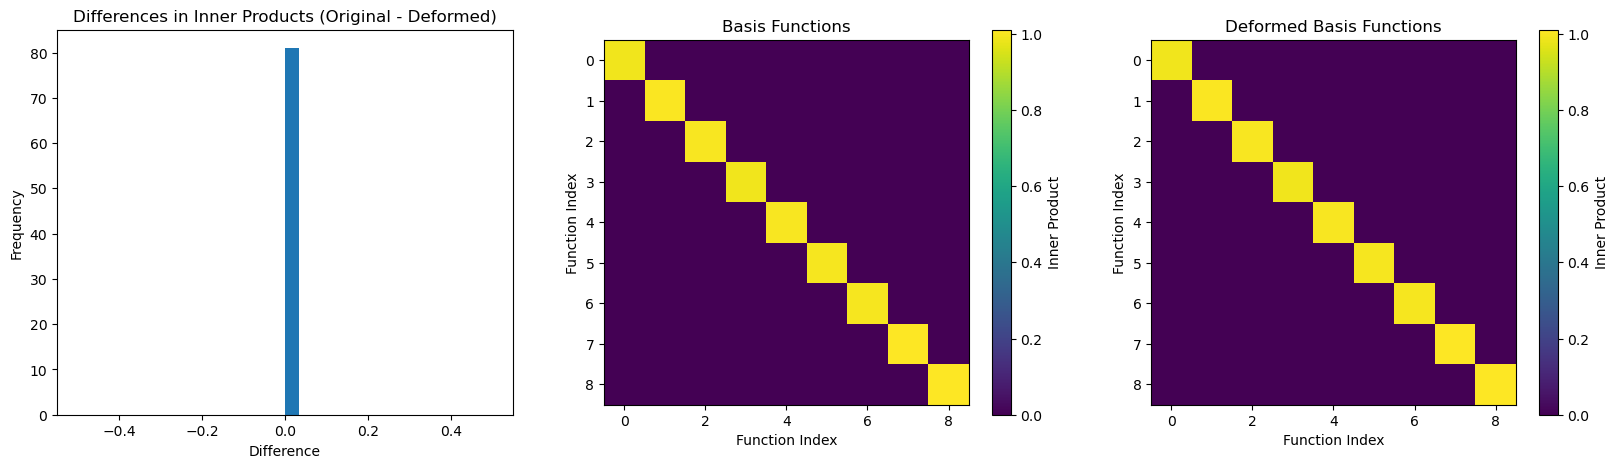

In [16]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product
# compute pairwise inner products
inner_products = pairwise_inner_product(all_vals, all_vals)
inner_products_deformed = pairwise_inner_product(all_deformed_vals, all_deformed_vals, logabsdet=logabsdet)

fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
